In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path

import zuko
import torch

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Dataset preparation

## Natural disaster datasets

### Load and clean the datasets

In [2]:
# Define paths to the storm events CSV files
data_dir = Path('datasets')
files = [
    data_dir / 'StormEvents_details-ftp_v1.0_d2016_c20250818.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2017_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2018_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2019_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2020_c20251118.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2021_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2022_c20250721.csv',
]

# Load datasets
print("Loading datasets...")
df_list = []
for file in files:
    # print(f"  Loading {file.name}...")
    df = pd.read_csv(file)
    # print(f"    Shape: {df.shape}")
    df_list.append(df)

# Concatenate the datasets
df = pd.concat(df_list, ignore_index=True)
print(f"\nCombined dataset shape: {df.shape}")

Loading datasets...

Combined dataset shape: (436146, 51)


In [3]:
useless_cols = [
    'BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME', 
    'END_YEARMONTH', 'END_DAY', 'END_TIME',
    'EPISODE_ID', 'EVENT_ID',
    'SOURCE',
    'YEAR',
    'MONTH_NAME',
    'WFO',
    'CATEGORY',
    'TOR_OTHER_WFO', 'TOR_OTHER_CZ_STATE', 'TOR_OTHER_CZ_FIPS', 'TOR_OTHER_CZ_NAME',
    'CZ_NAME', 'CZ_TIMEZONE',
    'EPISODE_NARRATIVE', 'EVENT_NARRATIVE', 'DATA_SOURCE',
    
    'FLOOD_CAUSE',
    'TOR_LENGTH',
    'TOR_WIDTH',
    'BEGIN_RANGE',
    'BEGIN_AZIMUTH',
    'BEGIN_LOCATION',
    'END_RANGE',
    'END_AZIMUTH',
    'END_LOCATION',
    'END_LAT',
    'END_LON',
    'MAGNITUDE_TYPE',
    'TOR_F_SCALE',
]

df1 = df.drop(columns=useless_cols, inplace=False)

In [4]:
df1.columns

Index(['STATE', 'STATE_FIPS', 'EVENT_TYPE', 'CZ_TYPE', 'CZ_FIPS',
       'BEGIN_DATE_TIME', 'END_DATE_TIME', 'INJURIES_DIRECT',
       'INJURIES_INDIRECT', 'DEATHS_DIRECT', 'DEATHS_INDIRECT',
       'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'MAGNITUDE', 'BEGIN_LAT',
       'BEGIN_LON'],
      dtype='object')

### Aggregate features

In [5]:
df1['EVENT_TYPE'] = df1['EVENT_TYPE'].replace({
    'Thunderstorm Wind': 'Wind',
    'Hail': 'Hail',
    'Marine Hail': 'Hail',
    'Flood': 'Flood',
    'Flash Flood': 'Flood',
    'Coastal Flood': 'Flood',
    'Lakeshore Flood': 'Flood',
    'Winter Weather': 'Freeze',
    'Extreme Cold/Wind Chill': 'Freeze',
    'Frost/Freeze': 'Freeze',
    'Cold/Wind Chill': 'Freeze',
    'Freezing Fog': 'Freeze',
    'Heat': 'Heat',
    'Excessive Heat': 'Heat',
    'Heavy Snow': 'Snow',
    'Blizzard': 'Snow',
    'Lake-Effect Snow': 'Snow',
    'Sleet': 'Snow',
    'Winter Storm': 'Storm',
    'Marine Thunderstorm Wind': 'Storm',
    'Tornado': 'Storm',
    'Tropical Storm': 'Storm',
    'Dust Storm': 'Storm',
    'Funnel Cloud': 'Storm',
    'Ice Storm': 'Storm',
    'Waterspout': 'Storm',
    'Marine Tropical Storm': 'Storm',
    'Hurricane (Typhoon)': 'Storm',
    'Marine Hurricane/Typhoon': 'Storm',
    'High Wind':  'Wind',
    'Strong Wind':  'Wind',
    'Marine High Wind':  'Wind',
    'Marine Strong Wind':  'Wind',
    'Dense Fog':  'Fog',
    'Marine Dense Fog':  'Fog'
})

In [6]:
def damage_to_numeric(damage_str):
    if pd.isna(damage_str):
        return 0
    multipliers = {'K': 1_000, 'M': 1_000_000, 'B': 1_000_000_000}
    if damage_str[-1] in multipliers:
        try:
            value = float(damage_str[:-1])
            return value * multipliers[damage_str[-1]]
        except ValueError:
            return 0
    try:
        return float(damage_str)
    except ValueError:
        return 0   

df1['DAMAGES'] = df1['DAMAGE_PROPERTY'].apply(damage_to_numeric) + df1['DAMAGE_CROPS'].apply(damage_to_numeric)
df2 = df1.drop(columns=['DAMAGE_PROPERTY', 'DAMAGE_CROPS'], inplace=False)

In [7]:
df2['CASUALTIES'] = df2['INJURIES_DIRECT'].fillna(0) + df2['INJURIES_INDIRECT'].fillna(0) + df2['DEATHS_DIRECT'].fillna(0) + df2['DEATHS_INDIRECT'].fillna(0)
df3 = df2.drop(columns=['INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT', 'DEATHS_INDIRECT'], inplace=False)

Actually keep only few events type for first experiments

In [8]:
df2['EVENT_TYPE'].unique()

array(['Heavy Rain', 'Wind', 'Storm', 'Heat', 'Flood', 'Drought', 'Hail',
       'Freeze', 'Lightning', 'Wildfire', 'Snow', 'Fog', 'Avalanche',
       'High Surf', 'Debris Flow', 'Astronomical Low Tide', 'Rip Current',
       'Dust Devil', 'Storm Surge/Tide', 'Sneakerwave',
       'Marine Tropical Depression', 'Seiche', 'Tropical Depression',
       'Dense Smoke', 'Volcanic Ashfall', 'Tsunami'], dtype=object)

In [9]:
df3 = df3[df3['EVENT_TYPE'].isin(['Flood', 'Tornado', 'Hail', 'Storm', 'Tsunami', 'Freeze', 'Snow', 'Heat', 'Heavy Rain', 'Wildfire'])]

In [10]:
df3['EVENT_TYPE'].nunique()

9

### Create unique FIPS

Unique FIPS is created starting from FIPS state (2 numbers) + FIPS county (3 numbers) (fill with zero the entry with less than this numbers)

In [11]:
df3['FIPS'] = df3['STATE_FIPS'].astype(str).str.zfill(2) + df3['CZ_FIPS'].astype(str).str.zfill(3)
print(df3[['FIPS', 'STATE_FIPS', 'CZ_FIPS']].head(10))

     FIPS  STATE_FIPS  CZ_FIPS
0   45091          45       91
6   56001          56        1
7   56012          56       12
8   56013          56       13
9   92247          92      247
10  92263          92      263
14  09001           9        1
15  09013           9       13
19  36093          36       93
23  09013           9       13


In [12]:
df3.drop(columns=['STATE_FIPS', 'CZ_FIPS'], inplace=True)

### Encode features

In [13]:
# categorial -> numeric
df3['EVENT_TYPE'] = df3['EVENT_TYPE'].astype('category').cat.codes

In [14]:
# EVENT_TYPE one-hot encoding
enc = OneHotEncoder(sparse_output=False)
event_type_encoded = enc.fit_transform(df3[['EVENT_TYPE']])
event_type_df = pd.DataFrame(event_type_encoded, columns=[f"EVENT_TYPE_{cat}" for cat in enc.categories_[0]], index=df3.index)
                             
df4 = pd.concat([df3.drop(columns=['EVENT_TYPE'], inplace=False), event_type_df], axis=1)

In [15]:
df4.head()

,STATE,CZ_TYPE,BEGIN_DATE_TIME,END_DATE_TIME,MAGNITUDE,BEGIN_LAT,BEGIN_LON,DAMAGES,CASUALTIES,FIPS,EVENT_TYPE_0,EVENT_TYPE_1,EVENT_TYPE_2,EVENT_TYPE_3,EVENT_TYPE_4,EVENT_TYPE_5,EVENT_TYPE_6,EVENT_TYPE_7,EVENT_TYPE_8
0,SOUTH CAROLINA,C,15-JUL-16 17:15:00,15-JUL-16 17:15:00,NaN,34.940,-81.030,2000.0,0,45091,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,WYOMING,Z,04-DEC-16 03:00:00,05-DEC-16 06:00:00,NaN,NaN,NaN,0.0,0,56001,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7,WYOMING,Z,04-DEC-16 04:00:00,05-DEC-16 05:00:00,NaN,NaN,NaN,0.0,0,56012,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8,WYOMING,Z,04-DEC-16 04:00:00,05-DEC-16 05:00:00,NaN,NaN,NaN,0.0,0,56013,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,LAKE SUPERIOR,Z,12-JUL-16 01:30:00,12-JUL-16 01:35:00,41.0,46.969,-88.398,0.0,0,92247,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [16]:
# fill BEGIN_LAT and BEGIN_LON NaN values with the mean of their respective columns
df4['BEGIN_LAT'] = df4['BEGIN_LAT'].fillna(df4['BEGIN_LAT'].mean())
df4['BEGIN_LON'] = df4['BEGIN_LON'].fillna(df4['BEGIN_LON'].mean())

In [17]:
# encode time cols BEGIN_DATE_TIME and END_DATE_TIME
fmt = "%d-%b-%y %H:%M:%S"

df4['BEGIN_DATE_TIME'] = pd.to_datetime(df4['BEGIN_DATE_TIME'], format=fmt, errors='coerce')
df4['END_DATE_TIME'] = pd.to_datetime(df4['END_DATE_TIME'], format=fmt, errors='coerce')

 # Extract hour and day of year
for prefix in ['BEGIN', 'END']:
    dt_col = f'{prefix}_DATE_TIME'
    # Hour of day cyclical encoding
    df4[f'{prefix}_HOUR_sin'] = np.sin(2 * np.pi * df4[dt_col].dt.hour / 24)
    df4[f'{prefix}_HOUR_cos'] = np.cos(2 * np.pi * df4[dt_col].dt.hour / 24)
    # Day of year cyclical encoding
    df4[f'{prefix}_DOY_sin'] = np.sin(2 * np.pi * df4[dt_col].dt.dayofyear / 366)
    df4[f'{prefix}_DOY_cos'] = np.cos(2 * np.pi * df4[dt_col].dt.dayofyear / 366)

# Optionally drop original datetime columns
# df.drop(columns=['BEGIN_DATE_TIME', 'END_DATE_TIME'], inplace=True)

In [18]:
df4.columns

Index(['STATE', 'CZ_TYPE', 'BEGIN_DATE_TIME', 'END_DATE_TIME', 'MAGNITUDE',
       'BEGIN_LAT', 'BEGIN_LON', 'DAMAGES', 'CASUALTIES', 'FIPS',
       'EVENT_TYPE_0', 'EVENT_TYPE_1', 'EVENT_TYPE_2', 'EVENT_TYPE_3',
       'EVENT_TYPE_4', 'EVENT_TYPE_5', 'EVENT_TYPE_6', 'EVENT_TYPE_7',
       'EVENT_TYPE_8', 'BEGIN_HOUR_sin', 'BEGIN_HOUR_cos', 'BEGIN_DOY_sin',
       'BEGIN_DOY_cos', 'END_HOUR_sin', 'END_HOUR_cos', 'END_DOY_sin',
       'END_DOY_cos'],
      dtype='object')

In [19]:
df4.drop(columns=['MAGNITUDE', 'BEGIN_LAT', 'BEGIN_LON'], inplace=True)

In [20]:
df5 = df4[df4['CZ_TYPE'] == 'C'] # keep only disasters happend in a county (for which we have demographical information)

In [21]:
nd_df = df5.copy()
nd_df.head()

,STATE,CZ_TYPE,BEGIN_DATE_TIME,END_DATE_TIME,DAMAGES,CASUALTIES,FIPS,EVENT_TYPE_0,EVENT_TYPE_1,EVENT_TYPE_2,...,EVENT_TYPE_7,EVENT_TYPE_8,BEGIN_HOUR_sin,BEGIN_HOUR_cos,BEGIN_DOY_sin,BEGIN_DOY_cos,END_HOUR_sin,END_HOUR_cos,END_DOY_sin,END_DOY_cos
0,SOUTH CAROLINA,C,2016-07-15 17:15:00,2016-07-15 17:15:00,2000.0,0,45091,0.0,0.0,0.0,...,0.0,0.0,-0.965926,-0.258819,-0.238033,-0.971257,-0.965926,-2.588190e-01,-0.238033,-0.971257
19,NEW YORK,C,2016-08-02 03:00:00,2016-08-02 06:22:00,0.0,0,36093,1.0,0.0,0.0,...,0.0,0.0,0.707107,0.707107,-0.522133,-0.852864,1.000000,6.123234e-17,-0.522133,-0.852864
28,NEW YORK,C,2016-08-02 03:15:00,2016-08-02 06:22:00,0.0,0,36001,1.0,0.0,0.0,...,0.0,0.0,0.707107,0.707107,-0.522133,-0.852864,1.000000,6.123234e-17,-0.522133,-0.852864
29,NEW YORK,C,2016-08-02 03:00:00,2016-08-02 06:22:00,0.0,0,36001,1.0,0.0,0.0,...,0.0,0.0,0.707107,0.707107,-0.522133,-0.852864,1.000000,6.123234e-17,-0.522133,-0.852864
30,NEW YORK,C,2016-08-02 03:15:00,2016-08-02 06:22:00,0.0,0,36093,1.0,0.0,0.0,...,0.0,0.0,0.707107,0.707107,-0.522133,-0.852864,1.000000,6.123234e-17,-0.522133,-0.852864


In [22]:
nd_df.columns

Index(['STATE', 'CZ_TYPE', 'BEGIN_DATE_TIME', 'END_DATE_TIME', 'DAMAGES',
       'CASUALTIES', 'FIPS', 'EVENT_TYPE_0', 'EVENT_TYPE_1', 'EVENT_TYPE_2',
       'EVENT_TYPE_3', 'EVENT_TYPE_4', 'EVENT_TYPE_5', 'EVENT_TYPE_6',
       'EVENT_TYPE_7', 'EVENT_TYPE_8', 'BEGIN_HOUR_sin', 'BEGIN_HOUR_cos',
       'BEGIN_DOY_sin', 'BEGIN_DOY_cos', 'END_HOUR_sin', 'END_HOUR_cos',
       'END_DOY_sin', 'END_DOY_cos'],
      dtype='object')

### Normalize features

In [23]:
scaler = StandardScaler()

## County population datasets

In [24]:
url_county = data_dir / 'cc-est2024-alldata.csv'
cs_df1 = pd.read_csv(url_county, encoding='latin1')

In [25]:
cs_df1.head()

,SUMLEV,STATE,COUNTY,STNAME,CTYNAME,YEAR,AGEGRP,TOT_POP,TOT_MALE,TOT_FEMALE,...,HWAC_MALE,HWAC_FEMALE,HBAC_MALE,HBAC_FEMALE,HIAC_MALE,HIAC_FEMALE,HAAC_MALE,HAAC_FEMALE,HNAC_MALE,HNAC_FEMALE
0,50,1,1,Alabama,Autauga County,1,0,58800,28693,30107,...,963,844,132,116,42,33,22,25,19,10
1,50,1,1,Alabama,Autauga County,1,1,3491,1818,1673,...,93,60,17,11,3,0,11,1,3,0
2,50,1,1,Alabama,Autauga County,1,2,3663,1875,1788,...,92,77,6,9,9,4,0,1,1,2
3,50,1,1,Alabama,Autauga County,1,3,4189,2152,2037,...,94,93,12,13,1,3,2,2,3,1
4,50,1,1,Alabama,Autauga County,1,4,3876,1960,1916,...,79,79,9,11,5,3,2,4,3,2


In [26]:
url_landmass = data_dir / 'county_landmass.csv'
lm_df1 = pd.read_csv(url_landmass)

In [27]:
lm_df1.head()

,FIPS,FIPS_state,FIPS_county,state_abbrev,state,county,sq_mi,land_sq_mi,water_sq_mi
0,1001,1,1,AL,Alabama,Autauga,604.45,595.97,8.48
1,1003,1,3,AL,Alabama,Baldwin,2026.93,1596.35,430.58
2,1005,1,5,AL,Alabama,Barbour,904.52,884.90,19.61
3,1007,1,7,AL,Alabama,Bibb,626.16,623.03,3.14
4,1009,1,9,AL,Alabama,Blount,650.60,645.59,5.02


### Create unique FIPS

In [28]:
cs_df1['FIPS'] = cs_df1['STATE'].astype(str).str.zfill(2) + cs_df1['COUNTY'].astype(str).str.zfill(3)
print(cs_df1[['FIPS', 'STATE', 'COUNTY']].head(10))

    FIPS  STATE  COUNTY
0  01001      1       1
1  01001      1       1
2  01001      1       1
3  01001      1       1
4  01001      1       1
5  01001      1       1
6  01001      1       1
7  01001      1       1
8  01001      1       1
9  01001      1       1


In [29]:
lm_df1['FIPS'] = lm_df1['FIPS_state'].astype(str).str.zfill(2) + lm_df1['FIPS_county'].astype(str).str.zfill(3)
print(lm_df1[['FIPS', 'FIPS_state', 'FIPS_county']].head(10))

    FIPS  FIPS_state  FIPS_county
0  01001           1            1
1  01003           1            3
2  01005           1            5
3  01007           1            7
4  01009           1            9
5  01011           1           11
6  01013           1           13
7  01015           1           15
8  01017           1           17
9  01019           1           19


### Keep only useful columns

In [30]:
cs_df2 = cs_df1[cs_df1['YEAR'] == 2]    # Keep only one population estimation for a fixed year (2020)
cs_df3 = cs_df2[cs_df2['AGEGRP'] == 0]  # Keep only the total population estimation per county (all races, all ages,...)
print(cs_df3.shape, cs_df2.shape, cs_df1.shape)

(3144, 81) (59736, 81) (358416, 81)


In [31]:
cs_df = cs_df3.drop(columns=['SUMLEV', 'STATE', 'COUNTY', 'STNAME', 'CTYNAME', 'YEAR', 'AGEGRP','TOT_MALE', 'TOT_FEMALE', 'WA_MALE', 'WA_FEMALE', 'BA_MALE',
       'BA_FEMALE', 'IA_MALE', 'IA_FEMALE', 'AA_MALE', 'AA_FEMALE', 'NA_MALE',
       'NA_FEMALE', 'TOM_MALE', 'TOM_FEMALE', 'WAC_MALE', 'WAC_FEMALE',
       'BAC_MALE', 'BAC_FEMALE', 'IAC_MALE', 'IAC_FEMALE', 'AAC_MALE',
       'AAC_FEMALE', 'NAC_MALE', 'NAC_FEMALE', 'NH_MALE', 'NH_FEMALE',
       'NHWA_MALE', 'NHWA_FEMALE', 'NHBA_MALE', 'NHBA_FEMALE', 'NHIA_MALE',
       'NHIA_FEMALE', 'NHAA_MALE', 'NHAA_FEMALE', 'NHNA_MALE', 'NHNA_FEMALE',
       'NHTOM_MALE', 'NHTOM_FEMALE', 'NHWAC_MALE', 'NHWAC_FEMALE',
       'NHBAC_MALE', 'NHBAC_FEMALE', 'NHIAC_MALE', 'NHIAC_FEMALE',
       'NHAAC_MALE', 'NHAAC_FEMALE', 'NHNAC_MALE', 'NHNAC_FEMALE', 'H_MALE',
       'H_FEMALE', 'HWA_MALE', 'HWA_FEMALE', 'HBA_MALE', 'HBA_FEMALE',
       'HIA_MALE', 'HIA_FEMALE', 'HAA_MALE', 'HAA_FEMALE', 'HNA_MALE',
       'HNA_FEMALE', 'HTOM_MALE', 'HTOM_FEMALE', 'HWAC_MALE', 'HWAC_FEMALE',
       'HBAC_MALE', 'HBAC_FEMALE', 'HIAC_MALE', 'HIAC_FEMALE', 'HAAC_MALE',
       'HAAC_FEMALE', 'HNAC_MALE', 'HNAC_FEMALE'], inplace=False)

In [32]:
cs_df.head()

,TOT_POP,FIPS
19,58909,01001
133,233244,01003
247,24975,01005
361,22176,01007
475,59110,01009


In [33]:
lm_df = lm_df1.drop(columns=['FIPS_state', 'FIPS_county', 'state_abbrev', 'state', 'county', 'sq_mi'], inplace=False)

In [34]:
lm_df.head()

,FIPS,land_sq_mi,water_sq_mi
0,01001,595.97,8.48
1,01003,1596.35,430.58
2,01005,884.90,19.61
3,01007,623.03,3.14
4,01009,645.59,5.02


## Merge datasets

In [35]:
X = nd_df.merge(cs_df, on='FIPS', how='left')
X = X.merge(lm_df, on='FIPS', how='left')
X.shape

(127899, 27)

In [36]:
print(f"Null values in the datasets:\n{X.isna().sum()}")

Null values in the datasets:
STATE                 0
CZ_TYPE               0
BEGIN_DATE_TIME       0
END_DATE_TIME         0
DAMAGES               0
CASUALTIES            0
FIPS                  0
EVENT_TYPE_0          0
EVENT_TYPE_1          0
EVENT_TYPE_2          0
EVENT_TYPE_3          0
EVENT_TYPE_4          0
EVENT_TYPE_5          0
EVENT_TYPE_6          0
EVENT_TYPE_7          0
EVENT_TYPE_8          0
BEGIN_HOUR_sin        0
BEGIN_HOUR_cos        0
BEGIN_DOY_sin         0
BEGIN_DOY_cos         0
END_HOUR_sin          0
END_HOUR_cos          0
END_DOY_sin           0
END_DOY_cos           0
TOT_POP            1507
land_sq_mi         1271
water_sq_mi        1271
dtype: int64


In [37]:
X = X.dropna()
print(f"Null values in the datasets:\n{X.isna().sum()}")

Null values in the datasets:
STATE              0
CZ_TYPE            0
BEGIN_DATE_TIME    0
END_DATE_TIME      0
DAMAGES            0
CASUALTIES         0
FIPS               0
EVENT_TYPE_0       0
EVENT_TYPE_1       0
EVENT_TYPE_2       0
EVENT_TYPE_3       0
EVENT_TYPE_4       0
EVENT_TYPE_5       0
EVENT_TYPE_6       0
EVENT_TYPE_7       0
EVENT_TYPE_8       0
BEGIN_HOUR_sin     0
BEGIN_HOUR_cos     0
BEGIN_DOY_sin      0
BEGIN_DOY_cos      0
END_HOUR_sin       0
END_HOUR_cos       0
END_DOY_sin        0
END_DOY_cos        0
TOT_POP            0
land_sq_mi         0
water_sq_mi        0
dtype: int64


### Prepare data for the models

In [38]:
y = X['DAMAGES'].copy()
X = X.drop(columns=['STATE', 'CZ_TYPE', 'BEGIN_DATE_TIME', 'END_DATE_TIME', 'DAMAGES', 'CASUALTIES', 'FIPS'])
print(X.shape, y.shape)

(126307, 20) (126307,)


In [39]:
# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
# Converti a numpy
X_train_np = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
y_train_np = y_train.values if isinstance(y_train, pd.Series) else y_train
X_test_np = X_test.values if isinstance(X_test, pd.DataFrame) else X_test
y_test_np = y_test.values if isinstance(y_test, pd.Series) else y_test

# Converti a PyTorch tensors
train_context = torch.tensor(X_train_np, dtype=torch.float32)
train_damage = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)  # Shape: (N, 1)
test_context = torch.tensor(X_test_np, dtype=torch.float32)
test_damage = torch.tensor(y_test_np, dtype=torch.float32).unsqueeze(1)

print(f"train_context shape: {train_context.shape}")
print(f"train_damage shape: {train_damage.shape}")

train_context shape: torch.Size([101045, 20])
train_damage shape: torch.Size([101045, 1])


In [41]:
# Log-transform (perché i danni sono molto skewed)
train_damage_log = torch.log(train_damage + 1.0)  # +1 per evitare log(0)
test_damage_log = torch.log(test_damage + 1.0)

# Z-score normalization
damage_mean = train_damage_log.mean()
damage_std = train_damage_log.std()

train_damage_norm = (train_damage_log - damage_mean) / damage_std
test_damage_norm = (test_damage_log - damage_mean) / damage_std

In [42]:
print(f"Damage statistics (original):")
print(f"  Min: ${train_damage.min().item():.2f}")
print(f"  Max: ${train_damage.max().item():.2f}")
print(f"  Mean: ${train_damage.mean().item():.2f}")
print(f"  Std: ${train_damage.std().item():.2f}")

print(f"\nDamage statistics (normalized):")
print(f"  Min: {train_damage_norm.min().item():.4f}")
print(f"  Max: {train_damage_norm.max().item():.4f}")
print(f"  Mean: {train_damage_norm.mean().item():.4f}")
print(f"  Std: {train_damage_norm.std().item():.4f}")

Damage statistics (original):
  Min: $0.00
  Max: $10000010240.00
  Mean: $582637.25
  Std: $44476880.00

Damage statistics (normalized):
  Min: -0.4397
  Max: 5.4551
  Mean: 0.0000
  Std: 1.0000


## Neural Spline Flow (NSF)

### Create the model

In [43]:
# Configuration parameters
n_context_features = train_context.shape[1] # what we pass to the model as conditions
n_sample_feature = 1    # what we want to predict (the damage)

In [44]:
nsf = zuko.flows.NSF(
    features=n_sample_feature,
    context=n_context_features,
    transforms=5,   # number of transformation layers
    hidden_features=[128, 128, 128]    # hidden layer sizes in the NN
)

print(f"NSF model created with {sum(p.numel() for p in nsf.parameters())} parameters")

NSF model created with 193395 parameters


### Training

In [45]:
# Training parameters
n_epochs = 50
lr=1e-3
batch_size=256

In [ ]:
# Prepare the data
train_dataset = torch.utils.data.TensorDataset(train_context, train_damage_norm)
test_dataset = torch.utils.data.TensorDataset(test_context, test_damage_norm)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [47]:
# Setup optimizer
optimizer = torch.optim.Adam(nsf.parameters(), lr=lr)

In [48]:
# Setup rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

In [49]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
nsf = nsf.to(device)
print(f"Model moved to {device}")

Model moved to cuda


In [ ]:
# Training loop
train_losses = []
test_losses = []
for epoch in range(n_epochs):
    # ===== TRAINING MODE =====
    nsf.train()
    epoch_train_loss = 0
    n_train_batches = 0
    
    for context_batch, damage_batch in train_loader:
        context_batch = context_batch.to(device)
        damage_batch = damage_batch.to(device)
        # Forward pass:
        dist = nsf(context_batch)
        
        # Compute negative log-likelihood
        loss = -dist.log_prob(damage_batch).mean()
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping (better for stability)
        torch.nn.utils.clip_grad_norm_(nsf.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        epoch_train_loss += loss.item()
        n_train_batches += 1
    
    avg_train_loss = epoch_train_loss / n_train_batches
    train_losses.append(avg_train_loss)
    
    # ===== EVALUATION MODE =====
    nsf.eval()
    epoch_test_loss = 0
    n_test_batches = 0
    
    with torch.no_grad():
        for context_batch, damage_batch in test_loader:
            context_batch = context_batch.to(device)
            damage_batch = damage_batch.to(device)
            
            dist = nsf(context_batch)
            loss = -dist.log_prob(damage_batch).mean()
            epoch_test_loss += loss.item()
            n_test_batches += 1
    
    avg_test_loss = epoch_test_loss / n_test_batches
    test_losses.append(avg_test_loss)
    
    # Update learning rate scheduler
    scheduler.step(avg_test_loss)
    
    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{n_epochs}] "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Test Loss: {avg_test_loss:.4f}")

Epoch [1/50] Train Loss: 3.3315 | Test Loss: 8.9919
Epoch [5/50] Train Loss: 0.9692 | Test Loss: 0.7208
Epoch [10/50] Train Loss: 0.9540 | Test Loss: 0.6809
Epoch [15/50] Train Loss: 0.4824 | Test Loss: 0.0617
Epoch [20/50] Train Loss: -1.4363 | Test Loss: -1.5699
Epoch [25/50] Train Loss: -2.7013 | Test Loss: -3.7158
Epoch [30/50] Train Loss: -3.5237 | Test Loss: -4.0718
Epoch [35/50] Train Loss: -3.7159 | Test Loss: -4.1534
Epoch [40/50] Train Loss: -3.3926 | Test Loss: -4.0517
Epoch [45/50] Train Loss: -4.2656 | Test Loss: -4.1543
Epoch [50/50] Train Loss: -4.1222 | Test Loss: -4.8282


### Inference

In [77]:
nsf.eval()

with torch.no_grad():
    # Move data to device
    test_context_gpu = test_context.to(device)
    
    # Get conditional distribution for all test samples
    test_dist = nsf(test_context_gpu)
    
    # Monte Carlo sampling to capture uncertainty
    n_samples = 1000
    print(f"      Generating {n_samples} samples per test event...")
    
    # Samples are in NORMALIZED space
    predicted_samples_norm = test_dist.sample((n_samples,))  # Shape: (n_samples, n_test, 1)
    
    # Compute statistics in NORMALIZED space
    predicted_mean_norm = predicted_samples_norm.mean(dim=0)
    predicted_std_norm = predicted_samples_norm.std(dim=0)
    predicted_median_norm = predicted_samples_norm.median(dim=0).values
    
    # Compute quantiles in NORMALIZED space
    quantiles_norm = torch.quantile(
        predicted_samples_norm, 
        torch.tensor([0.05, 0.25, 0.5, 0.75, 0.95], device=device),
        dim=0
    )
    q05_norm, q25_norm, q50_norm, q75_norm, q95_norm = quantiles_norm
    
    # De-normalize function (from normalized space to dollars)
    def denormalize_damage(damage_norm):
        """Convert from normalized space to dollars"""
        # damage_norm is in z-score space
        # First: un-normalize to log space
        damage_log = damage_norm * damage_std + damage_mean
        # Second: exp to get back to dollars (subtract 1 because we added 1 before log)
        damage_dollars = torch.exp(damage_log) - 1.0
        return damage_dollars
    
    # De-normalize ALL samples first (to preserve distribution shape)
    predicted_samples_dollars = denormalize_damage(predicted_samples_norm)
    
    # Now compute statistics in DOLLAR space
    pred_mean_dollars = predicted_samples_dollars.mean(dim=0)
    pred_std_dollars = predicted_samples_dollars.std(dim=0)
    pred_median_dollars = predicted_samples_dollars.median(dim=0).values
    
    # Compute quantiles in DOLLAR space
    quantiles_dollars = torch.quantile(
        predicted_samples_dollars,
        torch.tensor([0.05, 0.25, 0.5, 0.75, 0.95], device=device),
        dim=0
    )
    q05_dollars, q25_dollars, q50_dollars, q75_dollars, q95_dollars = quantiles_dollars
    
    # Move everything to CPU
    pred_mean_cpu = pred_mean_dollars.cpu()
    pred_std_cpu = pred_std_dollars.cpu()
    pred_median_cpu = pred_median_dollars.cpu()
    q05_cpu = q05_dollars.cpu()
    q25_cpu = q25_dollars.cpu()
    q50_cpu = q50_dollars.cpu()
    q75_cpu = q75_dollars.cpu()
    q95_cpu = q95_dollars.cpu()
    predicted_samples_cpu = predicted_samples_dollars.cpu()
    
    # Ground truth (already in dollars, already on CPU)
    true_damage_cpu = test_damage.cpu()

      Generating 1000 samples per test event...


### Performance metrics

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [78]:
# Convert to numpy
pred_mean_np = pred_mean_cpu.squeeze().numpy()
pred_std_np = pred_std_cpu.squeeze().numpy()
true_np = true_damage_cpu.squeeze().numpy()

# Sanity check
print(f"\n      Data ranges:")
print(f"      - True damage:      ${true_np.min():,.2f} to ${true_np.max():,.2f}")
print(f"      - Predicted damage: ${pred_mean_np.min():,.2f} to ${pred_mean_np.max():,.2f}")
print(f"      - Predicted std:    ${pred_std_np.min():,.2f} to ${pred_std_np.max():,.2f}")

# Main metrics
mae = mean_absolute_error(true_np, pred_mean_np)
rmse = np.sqrt(mean_squared_error(true_np, pred_mean_np))
r2 = r2_score(true_np, pred_mean_np)

# MAPE (avoiding division by zero)
mape = np.mean(np.abs((true_np - pred_mean_np) / (true_np + 1))) * 100

print(f"\n      Global Metrics:")
print(f"      - MAE:  ${mae:,.2f}")
print(f"      - RMSE: ${rmse:,.2f}")
print(f"      - R²:   {r2:.4f}")
print(f"      - MAPE: {mape:.2f}%")

# Check if R² is negative
if r2 < 0:
    print(f"\n      WARNING: R² is negative ({r2:.4f})")
    print(f"      This means the model performs worse than predicting the mean.")
    print(f"      Mean of true values: ${true_np.mean():,.2f}")
    print(f"      Mean of predictions: ${pred_mean_np.mean():,.2f}")

# Metrics by damage range
damage_ranges = [1000, 10000, 100000, 1000000]
print(f"\n      Metrics by Damage Range:")

for threshold in damage_ranges:
    mask = true_np > threshold
    if mask.sum() > 10:
        mae_range = mean_absolute_error(true_np[mask], pred_mean_np[mask])
        r2_range = r2_score(true_np[mask], pred_mean_np[mask])
        n_samples_range = mask.sum()
        print(f"      - Damage > ${threshold:,}: n={n_samples_range}, MAE=${mae_range:,.0f}, R²={r2_range:.3f}")



      Data ranges:
      - True damage:      $0.00 to $10,000,100,352.00
      - Predicted damage: $5.04 to $77,543,248.00
      - Predicted std:    $159.28 to $339,899,456.00

      Global Metrics:
      - MAE:  $31,784,382.00
      - RMSE: $84,326,542.83
      - R²:   -0.1809
      - MAPE: 2524274432.00%

      This means the model performs worse than predicting the mean.
      Mean of true values: $1,057,252.62
      Mean of predictions: $31,010,794.00

      Metrics by Damage Range:
      - Damage > $1,000: n=3895, MAE=$37,000,124, R²=-0.017
      - Damage > $10,000: n=2494, MAE=$39,199,564, R²=-0.006
      - Damage > $100,000: n=974, MAE=$51,294,532, R²=0.002
      - Damage > $1,000,000: n=290, MAE=$100,873,896, R²=-0.004


### Confidence analysis

In [65]:
from scipy.stats import spearmanr

In [79]:
# Compute prediction intervals
interval_width_90 = (q95_cpu - q05_cpu).squeeze().numpy()
interval_width_50 = (q75_cpu - q25_cpu).squeeze().numpy()

# Normalized confidence metric
confidence_metric = 1.0 / (pred_std_np / (pred_mean_np + 1))
confidence_metric_normalized = (confidence_metric - confidence_metric.min()) / (confidence_metric.max() - confidence_metric.min())

print(f"\n      Confidence Statistics:")
print(f"      - Mean prediction std: ${pred_std_np.mean():,.2f}")
print(f"      - Median prediction std: ${np.median(pred_std_np):,.2f}")
print(f"      - Mean 90% interval width: ${interval_width_90.mean():,.2f}")
print(f"      - Mean 50% interval width: ${interval_width_50.mean():,.2f}")

# Correlation between confidence and error
errors = pred_mean_np - true_np
abs_errors = np.abs(errors)

from scipy.stats import spearmanr
corr_conf_error, _ = spearmanr(pred_std_np, abs_errors)
print(f"\n      Confidence-Error Correlation:")
print(f"      - Spearman correlation (std vs abs_error): {corr_conf_error:.3f}")
if corr_conf_error > 0.3:
    print(f"        ✓ Well-calibrated (higher uncertainty → higher error)")
elif corr_conf_error > 0:
    print(f"        ~ Moderately calibrated")
else:
    print(f"        ✗ Poorly calibrated")

# Coverage analysis
print(f"\n      Calibration Analysis:")
for target_coverage in [50, 80, 90, 95]:
    lower_q = (1 - target_coverage/100) / 2
    upper_q = 1 - lower_q
    
    with torch.no_grad():
        quantiles_temp = torch.quantile(
            predicted_samples_dollars,
            torch.tensor([lower_q, upper_q], device=device),
            dim=0
        )
        lower_bound = quantiles_temp[0].cpu().squeeze().numpy()
        upper_bound = quantiles_temp[1].cpu().squeeze().numpy()
    
    in_interval = (true_np >= lower_bound) & (true_np <= upper_bound)
    actual_coverage = in_interval.mean() * 100
    
    calibration_error = abs(actual_coverage - target_coverage)
    status = "✓" if calibration_error < 5 else "✗"
    print(f"      {status} {target_coverage}% interval: actual coverage = {actual_coverage:.1f}% (error: {calibration_error:.1f}%)")



      Confidence Statistics:
      - Mean prediction std: $209,023,056.00
      - Median prediction std: $225,429,312.00
      - Mean 90% interval width: $446,322.25
      - Mean 50% interval width: $423.22

      Confidence-Error Correlation:
      - Spearman correlation (std vs abs_error): 0.996
        ✓ Well-calibrated (higher uncertainty → higher error)

      Calibration Analysis:
      ✗ 50% interval: actual coverage = 36.2% (error: 13.8%)
      ✗ 80% interval: actual coverage = 92.7% (error: 12.7%)
      ✗ 90% interval: actual coverage = 96.9% (error: 6.9%)
      ✓ 95% interval: actual coverage = 98.9% (error: 3.9%)


### Feature importance analysis

In [80]:
# Get feature names
if hasattr(X_train, 'columns'):
    feature_names = list(X_train.columns)
else:
    feature_names = [f"Feature_{i}" for i in range(test_context.shape[1])]

print(f"      Total features: {len(feature_names)}")

# Perturbation-based importance
print(f"\n      Computing perturbation-based importance...")
print(f"      (This may take a minute...)")

n_importance_samples = min(500, len(test_context))
test_subset = test_context[:n_importance_samples].clone()
test_subset_gpu = test_subset.to(device)

# Get baseline predictions
with torch.no_grad():
    baseline_dist = nsf(test_subset_gpu)
    baseline_samples = baseline_dist.sample((100,))
    baseline_mean = baseline_samples.mean(dim=0)

# Compute importance
feature_importance = np.zeros(len(feature_names))

for feat_idx in range(len(feature_names)):
    # Perturb feature
    perturbed_subset = test_subset.clone()
    shuffled_indices = torch.randperm(n_importance_samples)
    perturbed_subset[:, feat_idx] = test_subset[shuffled_indices, feat_idx]
    perturbed_subset_gpu = perturbed_subset.to(device)
    
    # Get predictions
    with torch.no_grad():
        perturbed_dist = nsf(perturbed_subset_gpu)
        perturbed_samples = perturbed_dist.sample((100,))
        perturbed_mean = perturbed_samples.mean(dim=0)
    
    # Measure change
    prediction_change = torch.abs(perturbed_mean - baseline_mean).mean().cpu().item()
    feature_importance[feat_idx] = prediction_change

# Normalize
feature_importance = feature_importance / (feature_importance.sum() + 1e-10)

# Get top features
top_n_features = 15
top_indices = np.argsort(feature_importance)[-top_n_features:][::-1]
top_features = [(feature_names[i], feature_importance[i]) for i in top_indices]

print(f"\n      Top {top_n_features} Most Important Features:")
for i, (feat_name, importance) in enumerate(top_features, 1):
    bar = '█' * int(importance * 200)
    print(f"      {i:2d}. {feat_name:35s} {importance*100:5.2f}% {bar}")

      Total features: 20

      Computing perturbation-based importance...
      (This may take a minute...)

      Top 15 Most Important Features:
       1. TOT_POP                              8.00% ███████████████
       2. END_DOY_cos                          5.01% ██████████
       3. EVENT_TYPE_7                         4.97% █████████
       4. EVENT_TYPE_4                         4.97% █████████
       5. EVENT_TYPE_0                         4.95% █████████
       6. land_sq_mi                           4.94% █████████
       7. EVENT_TYPE_1                         4.94% █████████
       8. EVENT_TYPE_5                         4.94% █████████
       9. END_HOUR_cos                         4.91% █████████
      10. BEGIN_DOY_sin                        4.90% █████████
      11. EVENT_TYPE_3                         4.88% █████████
      12. EVENT_TYPE_2                         4.86% █████████
      13. BEGIN_HOUR_sin                       4.83% █████████
      14. BEGIN_DOY_cos   

### Plots

In [64]:
# Plot styling
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/01_performance_analysis.png'

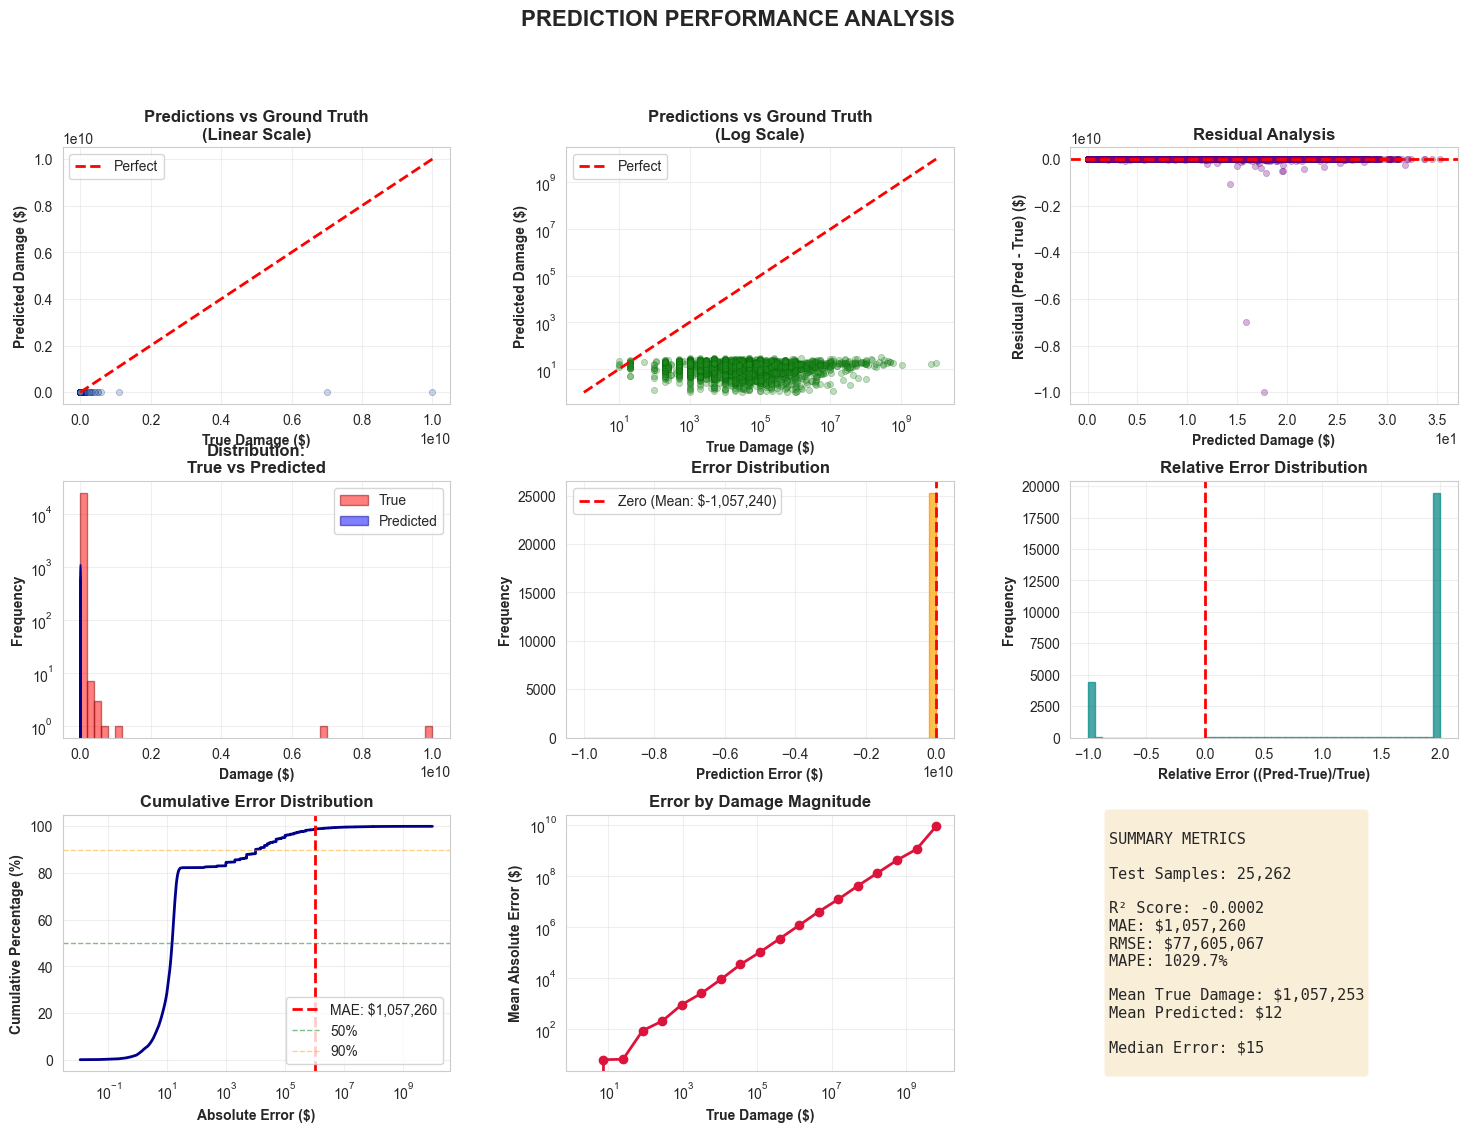

In [68]:
# === PLOT 1: Main Performance Analysis ===
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1.1 Predictions vs Ground Truth (linear)
ax = fig.add_subplot(gs[0, 0])
ax.scatter(true_np, pred_mean_np, alpha=0.3, s=20, c='steelblue', edgecolors='navy', linewidth=0.5)
max_val = max(true_np.max(), pred_mean_np.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect')
ax.set_xlabel('True Damage ($)', fontweight='bold')
ax.set_ylabel('Predicted Damage ($)', fontweight='bold')
ax.set_title('Predictions vs Ground Truth\n(Linear Scale)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

# 1.2 Predictions vs Ground Truth (log)
ax = fig.add_subplot(gs[0, 1])
mask_pos = (true_np > 1) & (pred_mean_np > 1)
ax.scatter(true_np[mask_pos], pred_mean_np[mask_pos], alpha=0.3, s=20, 
           c='forestgreen', edgecolors='darkgreen', linewidth=0.5)
ax.plot([1, max_val], [1, max_val], 'r--', linewidth=2, label='Perfect')
ax.set_xlabel('True Damage ($)', fontweight='bold')
ax.set_ylabel('Predicted Damage ($)', fontweight='bold')
ax.set_title('Predictions vs Ground Truth\n(Log Scale)', fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

# 1.3 Residuals
ax = fig.add_subplot(gs[0, 2])
ax.scatter(pred_mean_np, errors, alpha=0.3, s=20, c='purple', edgecolors='indigo', linewidth=0.5)
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Damage ($)', fontweight='bold')
ax.set_ylabel('Residual (Pred - True) ($)', fontweight='bold')
ax.set_title('Residual Analysis', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

# 1.4 Distribution comparison
ax = fig.add_subplot(gs[1, 0])
ax.hist(true_np, bins=50, alpha=0.5, color='red', label='True', edgecolor='darkred')
ax.hist(pred_mean_np, bins=50, alpha=0.5, color='blue', label='Predicted', edgecolor='darkblue')
ax.set_xlabel('Damage ($)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Distribution:\nTrue vs Predicted', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# 1.5 Error distribution
ax = fig.add_subplot(gs[1, 1])
ax.hist(errors, bins=50, alpha=0.7, color='orange', edgecolor='darkorange')
ax.axvline(x=0, color='r', linestyle='--', linewidth=2, label=f'Zero (Mean: ${np.mean(errors):,.0f})')
ax.set_xlabel('Prediction Error ($)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Error Distribution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 1.6 Relative error distribution
ax = fig.add_subplot(gs[1, 2])
relative_errors = errors / (true_np + 1)
relative_errors_clipped = np.clip(relative_errors, -2, 2)
ax.hist(relative_errors_clipped, bins=50, alpha=0.7, color='teal', edgecolor='darkcyan')
ax.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Relative Error ((Pred-True)/True)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Relative Error Distribution', fontweight='bold')
ax.grid(True, alpha=0.3)

# 1.7 Cumulative error
ax = fig.add_subplot(gs[2, 0])
sorted_abs_errors = np.sort(abs_errors)
cumulative = np.arange(1, len(sorted_abs_errors) + 1) / len(sorted_abs_errors) * 100
ax.plot(sorted_abs_errors, cumulative, linewidth=2, color='darkblue')
ax.axvline(x=mae, color='r', linestyle='--', linewidth=2, label=f'MAE: ${mae:,.0f}')
ax.axhline(y=50, color='g', linestyle='--', linewidth=1, alpha=0.5, label='50%')
ax.axhline(y=90, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='90%')
ax.set_xlabel('Absolute Error ($)', fontweight='bold')
ax.set_ylabel('Cumulative Percentage (%)', fontweight='bold')
ax.set_title('Cumulative Error Distribution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

# 1.8 Error by damage magnitude
ax = fig.add_subplot(gs[2, 1])
log_bins = np.logspace(0, np.log10(true_np.max() + 1), 20)
bin_indices = np.digitize(true_np, log_bins)
bin_errors = [abs_errors[bin_indices == i].mean() if (bin_indices == i).sum() > 0 else 0 
              for i in range(1, len(log_bins))]
bin_centers = (log_bins[:-1] + log_bins[1:]) / 2
ax.plot(bin_centers, bin_errors, 'o-', linewidth=2, markersize=6, color='crimson')
ax.set_xlabel('True Damage ($)', fontweight='bold')
ax.set_ylabel('Mean Absolute Error ($)', fontweight='bold')
ax.set_title('Error by Damage Magnitude', fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, which='both')

# 1.9 Summary metrics
ax = fig.add_subplot(gs[2, 2])
ax.axis('off')
summary_text = f"""
SUMMARY METRICS

Test Samples: {len(true_np):,}

R² Score: {r2:.4f}
MAE: ${mae:,.0f}
RMSE: ${rmse:,.0f}
MAPE: {mape:.1f}%

Mean True Damage: ${np.mean(true_np):,.0f}
Mean Predicted: ${np.mean(pred_mean_np):,.0f}

Median Error: ${np.median(abs_errors):,.0f}
"""
ax.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('PREDICTION PERFORMANCE ANALYSIS', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('/mnt/user-data/outputs/01_performance_analysis.png', dpi=300, bbox_inches='tight')
plt.close()
print("      Saved: 01_performance_analysis.png")


TypeError: quantile() received an invalid combination of arguments - got (Tensor, Tensor, dim=int, device=torch.device), but expected one of:
 * (Tensor input, Tensor q, int dim = None, bool keepdim = False, *, str interpolation = "linear", Tensor out = None)
 * (Tensor input, float q, int dim = None, bool keepdim = False, *, str interpolation = "linear", Tensor out = None)


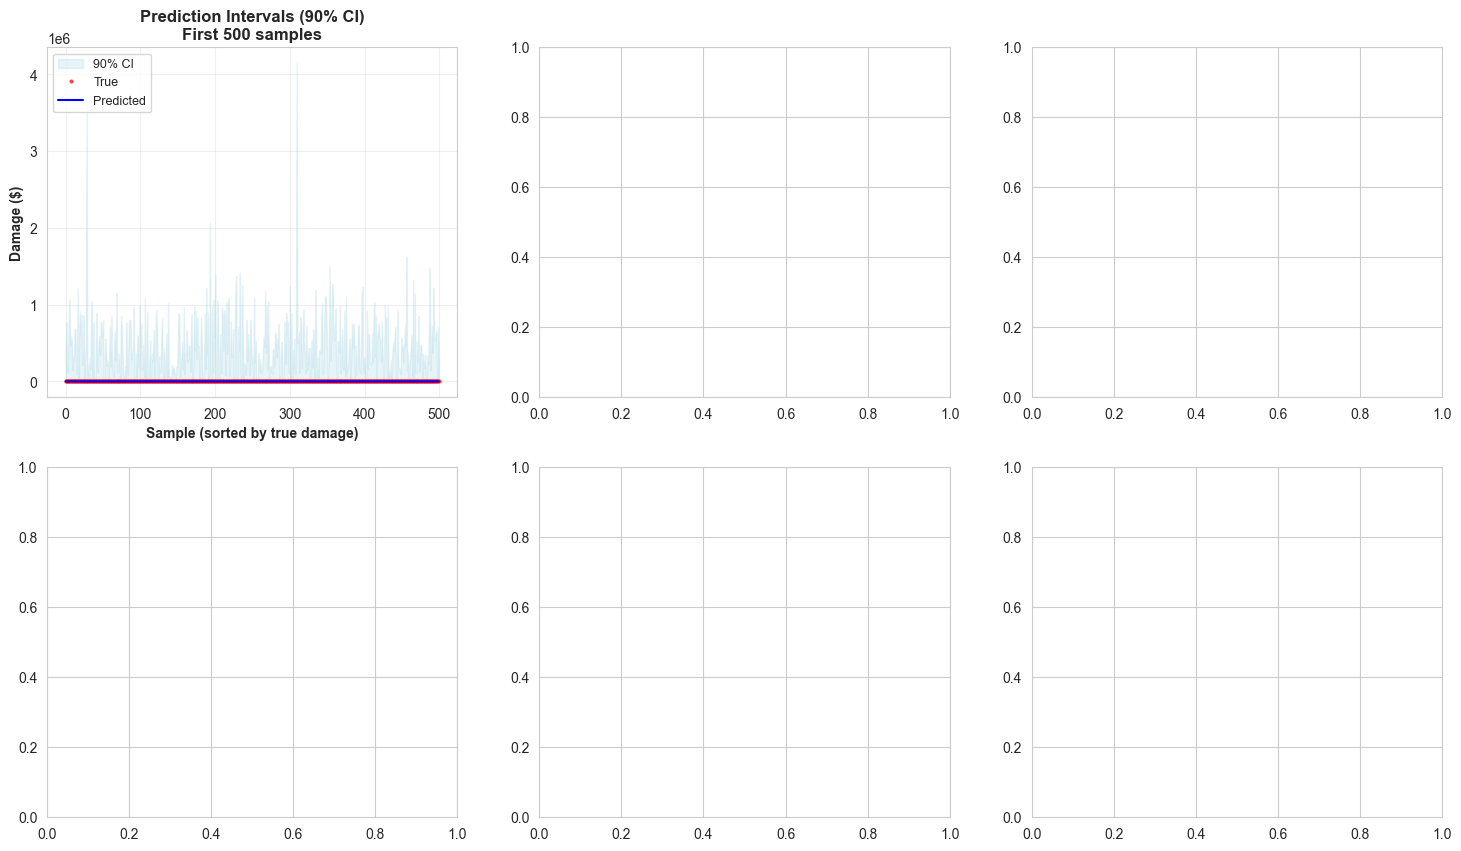

In [ ]:
# === PLOT 2: Confidence & Uncertainty Analysis ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 2.1 Prediction intervals
ax = axes[0, 0]
n_show = 500
sort_idx = np.argsort(true_np)[:n_show]
true_sorted = true_np[sort_idx]
pred_sorted = pred_mean_np[sort_idx]
q05_sorted = q05_cpu.squeeze().numpy()[sort_idx]
q95_sorted = q95_cpu.squeeze().numpy()[sort_idx]

x_plot = np.arange(len(true_sorted))
ax.fill_between(x_plot, q05_sorted, q95_sorted, alpha=0.3, color='lightblue', label='90% CI')
ax.plot(x_plot, true_sorted, 'o', markersize=2, alpha=0.6, color='red', label='True')
ax.plot(x_plot, pred_sorted, '-', linewidth=1.5, color='blue', label='Predicted')
ax.set_xlabel('Sample (sorted by true damage)', fontweight='bold')
ax.set_ylabel('Damage ($)', fontweight='bold')
ax.set_title(f'Prediction Intervals (90% CI)\nFirst {n_show} samples', fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

# 2.2 Calibration plot
ax = axes[0, 1]
confidence_levels = np.arange(0.1, 1.0, 0.05)
empirical_coverage = []

for conf in confidence_levels:
    lower_q = (1 - conf) / 2
    upper_q = 1 - lower_q
    
    with torch.no_grad():
        quantiles_temp = torch.quantile(
            predicted_samples,
            torch.tensor([lower_q, upper_q], device=device),
            dim=0
        )
        lower_bound = denormalize_damage(quantiles_temp[0]).cpu().squeeze().numpy()
        upper_bound = denormalize_damage(quantiles_temp[1]).cpu().squeeze().numpy()
    
    in_interval = (true_np >= lower_bound) & (true_np <= upper_bound)
    coverage = in_interval.mean()
    empirical_coverage.append(coverage)

ax.plot(confidence_levels * 100, np.array(empirical_coverage) * 100, 
         'o-', linewidth=2, markersize=6, color='darkblue', label='Empirical Coverage')
ax.plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect Calibration')
ax.fill_between([0, 100], [0, 100], alpha=0.1, color='red')
ax.set_xlabel('Nominal Confidence Level (%)', fontweight='bold')
ax.set_ylabel('Empirical Coverage (%)', fontweight='bold')
ax.set_title('Model Calibration', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 100])
ax.set_ylim([0, 100])

# 2.3 Uncertainty vs Error
ax = axes[0, 2]
ax.scatter(pred_std_np, abs_errors, alpha=0.3, s=20, c='purple', edgecolors='indigo', linewidth=0.5)
ax.set_xlabel('Predicted Std ($)', fontweight='bold')
ax.set_ylabel('Absolute Error ($)', fontweight='bold')
ax.set_title('Uncertainty vs Error', fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, which='both')
ax.text(0.05, 0.95, f'Spearman ρ: {corr_conf_error:.3f}', 
         transform=ax.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# 2.4 Interval width distribution
ax = axes[1, 0]
ax.hist(interval_width_90, bins=50, alpha=0.7, color='teal', edgecolor='darkcyan')
median_width = np.median(interval_width_90)
ax.axvline(median_width, color='r', linestyle='--', linewidth=2, 
           label=f'Median: ${median_width:,.0f}')
ax.set_xlabel('90% CI Width ($)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Confidence Interval Width Distribution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

# 2.5 Confidence by damage range
ax = axes[1, 1]
damage_percentiles = np.percentile(true_np, [0, 25, 50, 75, 100])
confidence_by_range = []
range_labels = []

for i in range(len(damage_percentiles)-1):
    mask = (true_np >= damage_percentiles[i]) & (true_np < damage_percentiles[i+1])
    if mask.sum() > 0:
        avg_confidence = pred_std_np[mask].mean()
        confidence_by_range.append(avg_confidence)
        range_labels.append(f'Q{i+1}')

x_pos = np.arange(len(confidence_by_range))
ax.bar(x_pos, confidence_by_range, alpha=0.7, color='steelblue', edgecolor='navy')
ax.set_xticks(x_pos)
ax.set_xticklabels(range_labels)
ax.set_xlabel('Damage Quartile', fontweight='bold')
ax.set_ylabel('Mean Predicted Std ($)', fontweight='bold')
ax.set_title('Confidence by Damage Range', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 2.6 High vs Low confidence examples
ax = axes[1, 2]
# Top 10% most confident and least confident
n_examples = len(pred_std_np) // 10
high_conf_idx = np.argsort(pred_std_np)[:n_examples]
low_conf_idx = np.argsort(pred_std_np)[-n_examples:]

high_conf_errors = abs_errors[high_conf_idx]
low_conf_errors = abs_errors[low_conf_idx]

bp = ax.boxplot([high_conf_errors, low_conf_errors], 
                labels=['High Confidence\n(Low Std)', 'Low Confidence\n(High Std)'],
                patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
ax.set_ylabel('Absolute Error ($)', fontweight='bold')
ax.set_title('Error Distribution by Confidence Level', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_yscale('log')

plt.suptitle('CONFIDENCE & UNCERTAINTY ANALYSIS', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/02_confidence_analysis.png', dpi=300, bbox_inches='tight')
plt.close()
print("      Saved: 02_confidence_analysis.png")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/03_feature_importance.png'

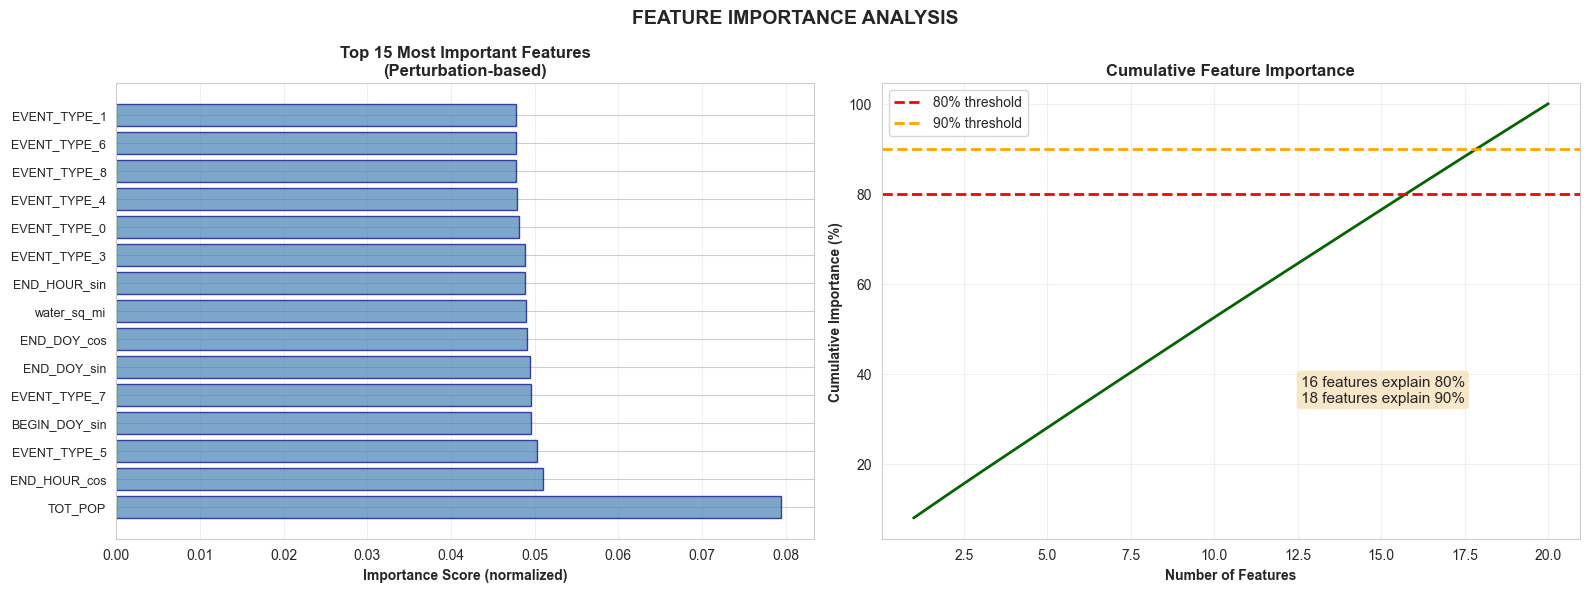

In [73]:
# === PLOT 3: Feature Importance ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3.1 Feature importance bar chart
ax = axes[0]
y_pos = np.arange(len(top_features))
importances = [imp for _, imp in top_features]
names = [name for name, _ in top_features]

ax.barh(y_pos, importances, alpha=0.7, color='steelblue', edgecolor='navy')
ax.set_yticks(y_pos)
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('Importance Score (normalized)', fontweight='bold')
ax.set_title(f'Top {top_n_features} Most Important Features\n(Perturbation-based)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 3.2 Cumulative importance
ax = axes[1]
sorted_importance = np.sort(feature_importance)[::-1]
cumulative_importance = np.cumsum(sorted_importance)
x_features = np.arange(1, len(sorted_importance) + 1)

ax.plot(x_features, cumulative_importance * 100, linewidth=2, color='darkgreen')
ax.axhline(y=80, color='r', linestyle='--', linewidth=2, label='80% threshold')
ax.axhline(y=90, color='orange', linestyle='--', linewidth=2, label='90% threshold')
ax.set_xlabel('Number of Features', fontweight='bold')
ax.set_ylabel('Cumulative Importance (%)', fontweight='bold')
ax.set_title('Cumulative Feature Importance', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Find number of features for 80% and 90%
n_80 = np.argmax(cumulative_importance >= 0.8) + 1
n_90 = np.argmax(cumulative_importance >= 0.9) + 1
ax.text(0.6, 0.3, f'{n_80} features explain 80%\n{n_90} features explain 90%',
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.suptitle('FEATURE IMPORTANCE ANALYSIS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/03_feature_importance.png', dpi=300, bbox_inches='tight')
plt.close()
print("      Saved: 03_feature_importance.png")


      Generating specific examples...


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/04_prediction_examples.png'

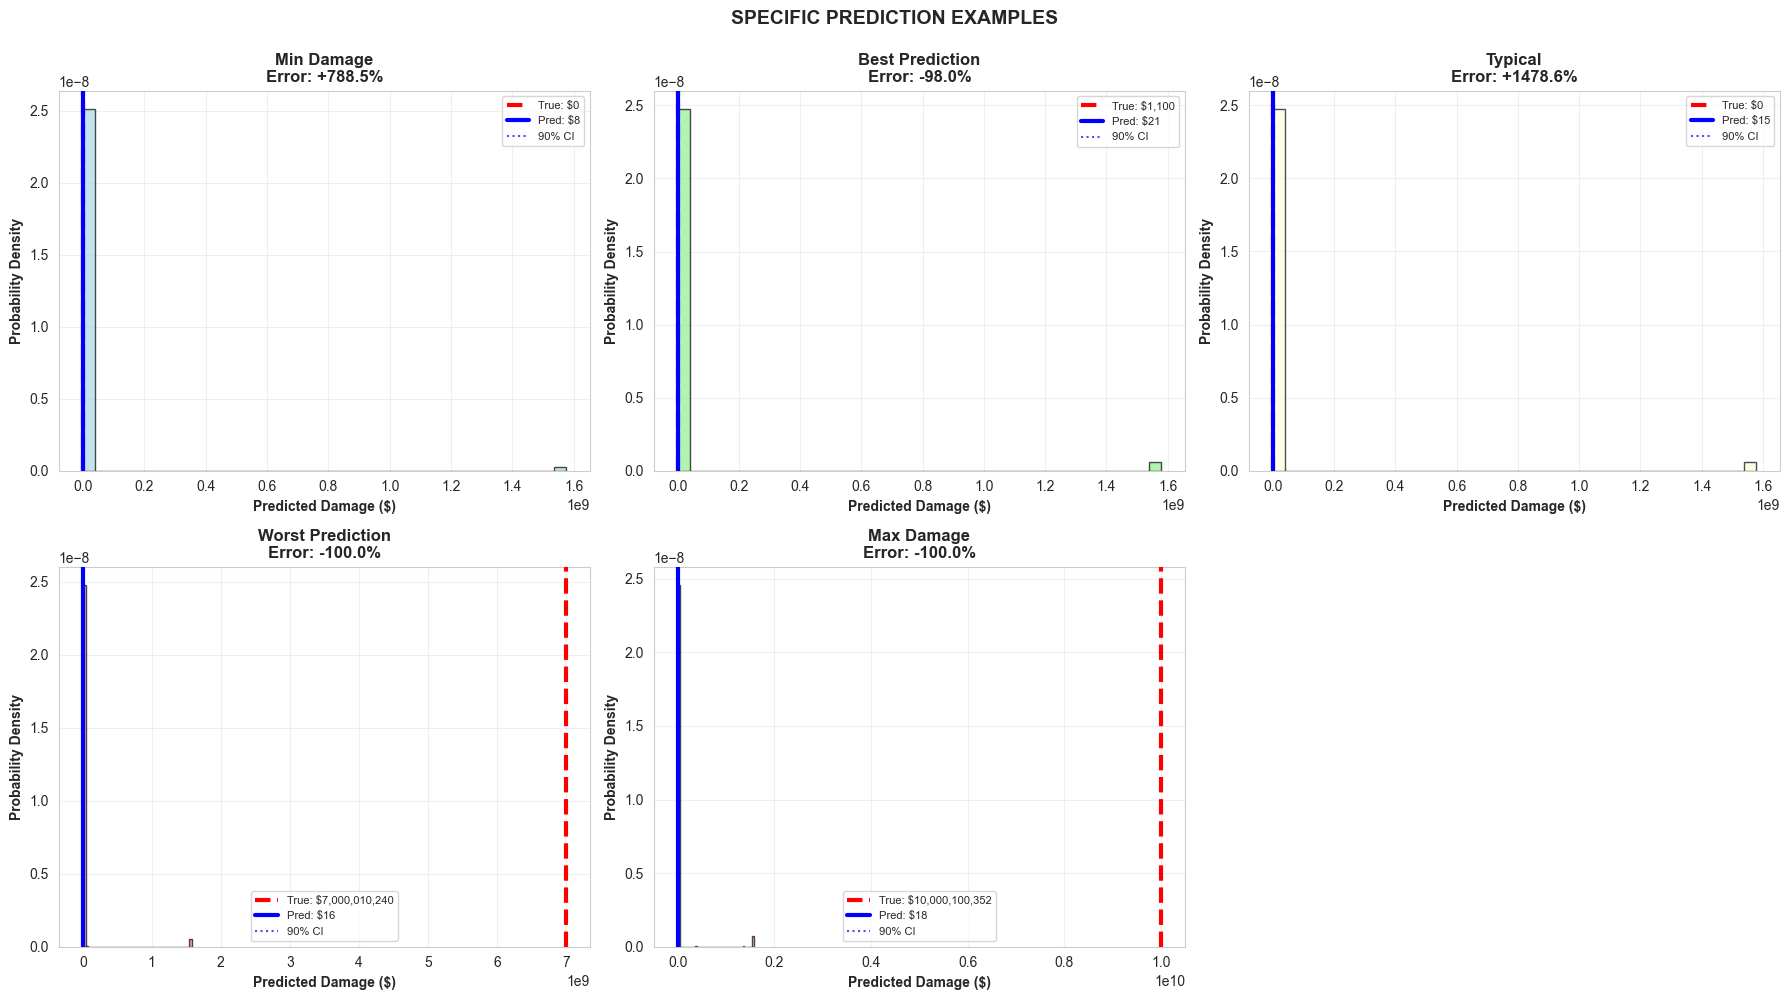

In [74]:
# === PLOT 4: Specific Prediction Examples ===
print("\n      Generating specific examples...")

# Select interesting examples
idx_min = np.argmin(true_np)
idx_median = np.argsort(true_np)[len(true_np)//2]
idx_high = np.argmax(true_np)

# Best prediction (minimum relative error for significant damages)
rel_errors_abs = np.abs(relative_errors)
significant_mask = true_np > 1000
good_candidates = np.where(significant_mask)[0]
idx_good = good_candidates[np.argmin(rel_errors_abs[good_candidates])]

# Worst prediction
bad_candidates = np.where(significant_mask)[0]
idx_bad = bad_candidates[np.argmax(rel_errors_abs[bad_candidates])]

# Typical prediction (error close to median)
median_error = np.median(abs_errors)
idx_typical = np.argmin(np.abs(abs_errors - median_error))

example_indices = [idx_min, idx_good, idx_typical, idx_bad, idx_high]
example_labels = ['Min Damage', 'Best Prediction', 'Typical', 'Worst Prediction', 'Max Damage']
example_colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral', 'lightpink']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (idx, label, color) in enumerate(zip(example_indices, example_labels, example_colors)):
    if i >= len(axes):
        break
        
    ax = axes[i]
    
    # Get samples for this event
    samples_norm = predicted_samples_cpu[:, idx, 0].numpy()
    samples_dollars = denormalize_damage(torch.tensor(samples_norm)).numpy()
    
    # Plot distribution
    ax.hist(samples_dollars, bins=40, alpha=0.7, color=color, edgecolor='black', density=True)
    
    # Add vertical lines
    ax.axvline(true_np[idx], color='red', linewidth=3, linestyle='--', 
               label=f'True: ${true_np[idx]:,.0f}', zorder=10)
    ax.axvline(pred_mean_np[idx], color='blue', linewidth=3, linestyle='-', 
               label=f'Pred: ${pred_mean_np[idx]:,.0f}', zorder=10)
    
    # Add confidence interval
    ax.axvline(q05_cpu.squeeze().numpy()[idx], color='blue', linewidth=1.5, 
              linestyle=':', alpha=0.7, label='90% CI', zorder=9)
    ax.axvline(q95_cpu.squeeze().numpy()[idx], color='blue', linewidth=1.5, 
              linestyle=':', alpha=0.7, zorder=9)
    
    # Calculate error percentage
    error_pct = ((pred_mean_np[idx] - true_np[idx]) / (true_np[idx] + 1)) * 100
    
    ax.set_xlabel('Predicted Damage ($)', fontweight='bold')
    ax.set_ylabel('Probability Density', fontweight='bold')
    ax.set_title(f'{label}\nError: {error_pct:+.1f}%', fontweight='bold')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    
    if true_np[idx] > 10000:
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

# Remove last subplot if not needed
if len(example_indices) < len(axes):
    fig.delaxes(axes[-1])

plt.suptitle('SPECIFIC PREDICTION EXAMPLES', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/04_prediction_examples.png', dpi=300, bbox_inches='tight')
plt.close()
print("      Saved: 04_prediction_examples.png")

# Print detailed example information
print("\n" + "-"*80)
print("DETAILED EXAMPLES")
print("-"*80)

for idx, label in zip(example_indices, example_labels):
    error_abs = pred_mean_np[idx] - true_np[idx]
    error_pct = (error_abs / (true_np[idx] + 1)) * 100
    
    print(f"\n{label}:")
    print(f"  True Damage:      ${true_np[idx]:,.2f}")
    print(f"  Predicted Mean:   ${pred_mean_np[idx]:,.2f}")
    print(f"  Predicted Std:    ${pred_std_cpu.squeeze().numpy()[idx]:,.2f}")
    print(f"  90% CI:           [${q05_cpu.squeeze().numpy()[idx]:,.2f}, "
          f"${q95_cpu.squeeze().numpy()[idx]:,.2f}]")
    print(f"  Absolute Error:   ${abs(error_abs):,.2f}")
    print(f"  Relative Error:   {error_pct:+.2f}%")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/05_top_damages.png'

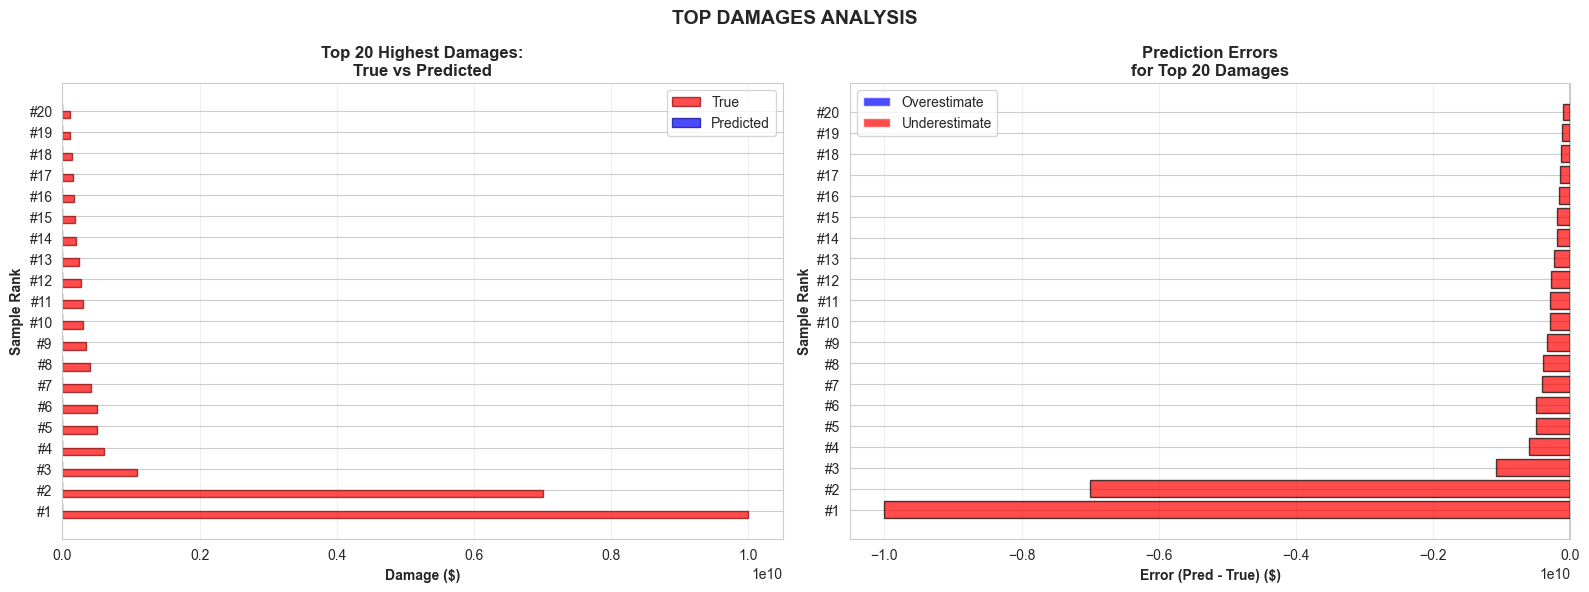

In [75]:
# === PLOT 5: Top Damages Comparison ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 5.1 Top damages comparison
ax = axes[0]
top_n = 20
top_indices = np.argsort(true_np)[-top_n:][::-1]

x_pos = np.arange(top_n)
width = 0.35

ax.barh(x_pos - width/2, true_np[top_indices], width, 
        label='True', color='red', alpha=0.7, edgecolor='darkred')
ax.barh(x_pos + width/2, pred_mean_np[top_indices], width, 
        label='Predicted', color='blue', alpha=0.7, edgecolor='darkblue')

ax.set_ylabel('Sample Rank', fontweight='bold')
ax.set_xlabel('Damage ($)', fontweight='bold')
ax.set_title(f'Top {top_n} Highest Damages:\nTrue vs Predicted', fontweight='bold')
ax.set_yticks(x_pos)
ax.set_yticklabels([f'#{i+1}' for i in range(top_n)])
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

# 5.2 Errors on top damages
ax = axes[1]
top_errors = pred_mean_np[top_indices] - true_np[top_indices]
colors = ['red' if e < 0 else 'blue' for e in top_errors]

ax.barh(x_pos, top_errors, color=colors, alpha=0.7, edgecolor='black')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.set_ylabel('Sample Rank', fontweight='bold')
ax.set_xlabel('Error (Pred - True) ($)', fontweight='bold')
ax.set_title(f'Prediction Errors\nfor Top {top_n} Damages', fontweight='bold')
ax.set_yticks(x_pos)
ax.set_yticklabels([f'#{i+1}' for i in range(top_n)])
ax.grid(True, alpha=0.3, axis='x')
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', alpha=0.7, label='Overestimate'),
                  Patch(facecolor='red', alpha=0.7, label='Underestimate')]
ax.legend(handles=legend_elements)

plt.suptitle('TOP DAMAGES ANALYSIS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/05_top_damages.png', dpi=300, bbox_inches='tight')
plt.close()
print("      Saved: 05_top_damages.png")


In [76]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("EVALUATION COMPLETE")
print("="*80)
print("\nOutput files saved to /mnt/user-data/outputs/:")
print("  1. 01_performance_analysis.png    - Overall prediction performance")
print("  2. 02_confidence_analysis.png     - Model confidence & uncertainty")
print("  3. 03_feature_importance.png      - Feature importance ranking")
print("  4. 04_prediction_examples.png     - Specific prediction examples")
print("  5. 05_top_damages.png             - Analysis of highest damages")
print("\n" + "="*80)
print("\nKey Insights:")
print(f"  • Model R²: {r2:.4f} ({'Good' if r2 > 0.7 else 'Fair' if r2 > 0.5 else 'Poor'} fit)")
print(f"  • Calibration: {('Well-calibrated' if abs(corr_conf_error) > 0.3 else 'Needs improvement')}")
print(f"  • Top feature: {top_features[0][0]} ({top_features[0][1]*100:.1f}% importance)")
print(f"  • {n_80} features explain 80% of prediction variance")
print("="*80)



EVALUATION COMPLETE

Output files saved to /mnt/user-data/outputs/:
  1. 01_performance_analysis.png    - Overall prediction performance
  2. 02_confidence_analysis.png     - Model confidence & uncertainty
  3. 03_feature_importance.png      - Feature importance ranking
  4. 04_prediction_examples.png     - Specific prediction examples
  5. 05_top_damages.png             - Analysis of highest damages


Key Insights:
  • Model R²: -0.0002 (Poor fit)
  • Calibration: Well-calibrated
  • Top feature: TOT_POP (7.9% importance)
  • 16 features explain 80% of prediction variance
